In [52]:
import matplotlib.pyplot as plt
import numpy as np
import os, glob
import pandas as pd
from pathlib import Path
from collections import namedtuple
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.interpolate import UnivariateSpline

plt.rcParams['text.usetex'] = False

stats = namedtuple('Statistics', ['x', 'avg_ent_real', 'avg_ent_gen', 'avg_ent_gap', 'ent_real', 'ent_gen'])

In [2]:
def normalization(arr):
    max_val = np.max(arr)
    return arr / max_val


def get_stats(folders, t: float, percentage=True, sort=False, normalized=False):    
    assert len(folders) > 0
    
    if sort:
        folders.sort(key = lambda f: float(Path(f).name))
        
    file_stats = stats([], [], [], [], [], [])
    
    for f in folders:
        x = float(Path(f).name)
        
        try:
            csv = glob.glob(os.path.join(f, f'entropy*_t={t}.csv'))[0]
        except:
            csv = glob.glob(os.path.join(f, f'entropy*_t={t}.csv'))
            print(csv, f)
            continue
        
        df = pd.read_csv(csv)
        npz = glob.glob(os.path.join(f, f'entropy*_t={t}.npz'))[0]
        npz = np.load(npz, allow_pickle=True)
        
        ent_real = npz['real_entropy']
        ent_gen = npz['synthetic_entropy']
        
        file_stats.x.append(x)
        file_stats.ent_gen.append(ent_gen)
        file_stats.ent_real.append(ent_real)
        file_stats.avg_ent_real.append(ent_real.mean())
        file_stats.avg_ent_gen.append(ent_gen.mean())
        
        file_stats.avg_ent_gap.append(
            file_stats.avg_ent_gen[-1] - file_stats.avg_ent_real[-1]
        )
        
    if normalized:
        avg_ent_real, avg_ent_gen, avg_ent_gap = map(normalization, (file_stats.avg_ent_real, file_stats.avg_ent_gen, file_stats.avg_ent_gap))
        new_file_stats = stats(file_stats.x, avg_ent_real, avg_ent_gen, avg_ent_gap, file_stats.ent_real, file_stats.ent_gen)    
        return new_file_stats
    
    return file_stats

In [75]:
model_size = 'tiny'
data_name = 'lm1b-wrap'
folder_path = f'../old-experiments/entropy/{data_name}-{model_size}/'

folders = glob.glob(os.path.join(folder_path, '*'))
folders.sort(
    key = lambda f: float(Path(f).name)
)

t = 0.00001
stats1 = get_stats(folders, t, normalized=False)

len(folders), folders

(38,
 ['../old-experiments/entropy/lm1b-wrap-tiny/0.0001',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.002575',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.00505',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.007525',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.01',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.04',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.07',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.1',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.13',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.16',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.19',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.22',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.25',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.28',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.31',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.34',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.37',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.4',
  '../old-experiments/entropy/lm1b-wrap-tiny/0.4

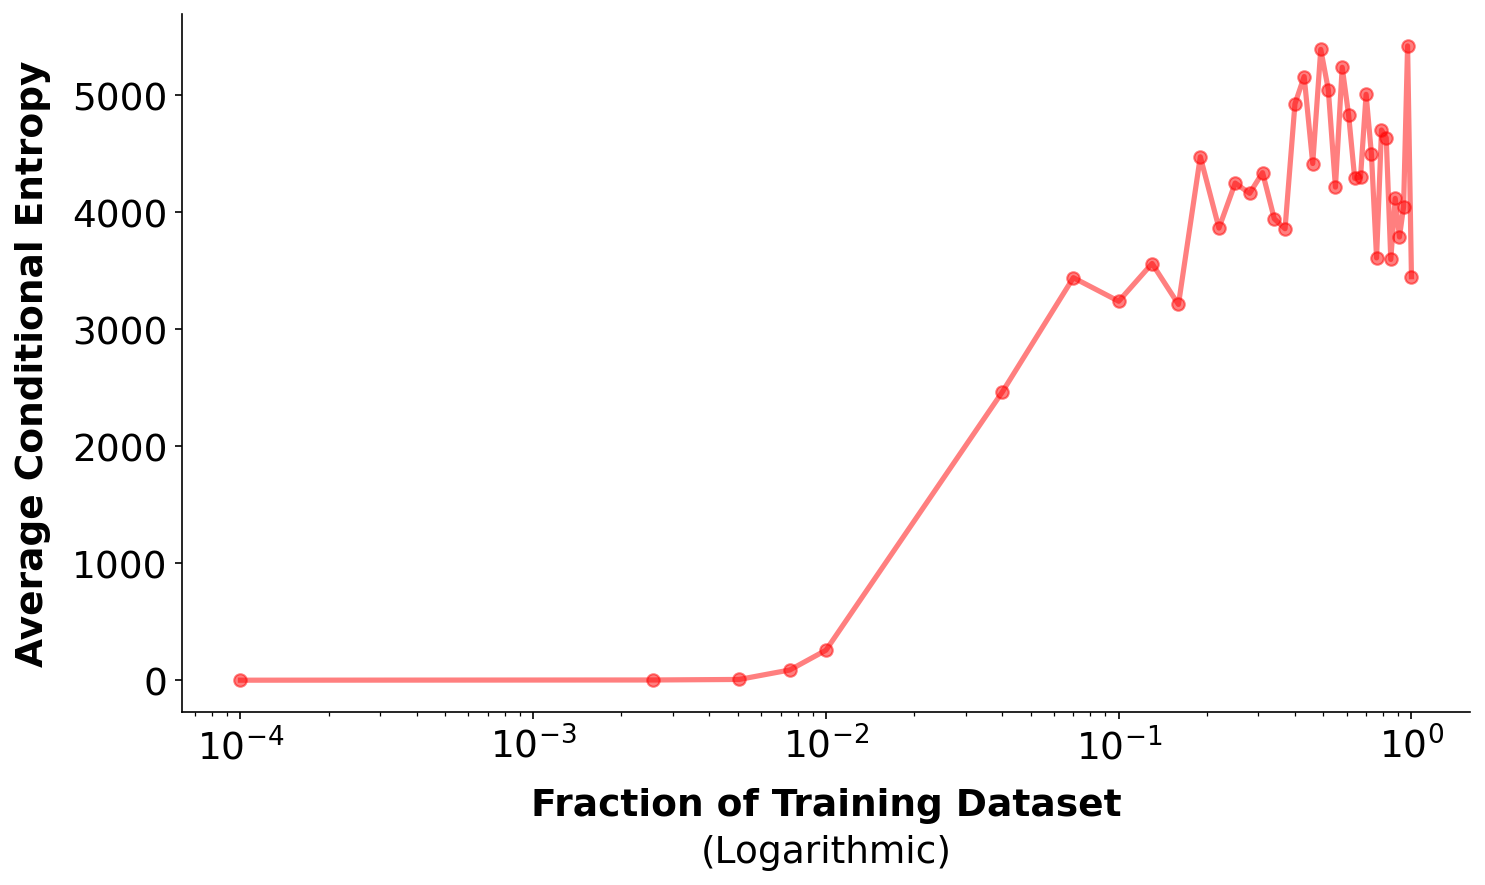

In [57]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
#plt.get_cmap('h')
#c = cm.OrRd_r(np.linspace(0, 1, 2))

fontsize=18
data = pd.DataFrame({'x':stats1.x, 'y': stats1.avg_ent_gen}).sort_values('x')

x = np.array(stats1.x).astype('float')
spl = UnivariateSpline(x, stats1.avg_ent_real, k=5)

ax.plot(stats1.x, spl(stats1.avg_ent_real), color='red', linestyle='-', marker='o', linewidth=2.5, alpha=0.5, label='Train')
# ax.plot(stats1.x, stats1.avg_ent_gen, color='blue', linestyle='-', marker='o', linewidth=2.5, alpha=0.5, label='Synthetic')

ax.set_xscale('log')
ax.set_xlabel('Fraction of Training Dataset', fontsize=fontsize, weight='bold', labelpad=10)
ax.set_ylabel('Average Conditional Entropy', fontsize=fontsize, weight='bold', labelpad=10)

ax.text(0.5, -0.175, '(Logarithmic)', transform=ax.transAxes, 
        fontsize=fontsize, weight='normal', ha='center', va='top')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Custom Legend Construction
from matplotlib.lines import Line2D
legend_elements = []
legend_elements.append(Line2D([0], [0], color='red', alpha=0.65, lw=2, label='Train'))
legend_elements.append(Line2D([0], [0], color='blue', alpha=0.65, lw=2, label='Synthetic'))

#ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize=10)
#ax.grid(True, which="major", ls=":")
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()

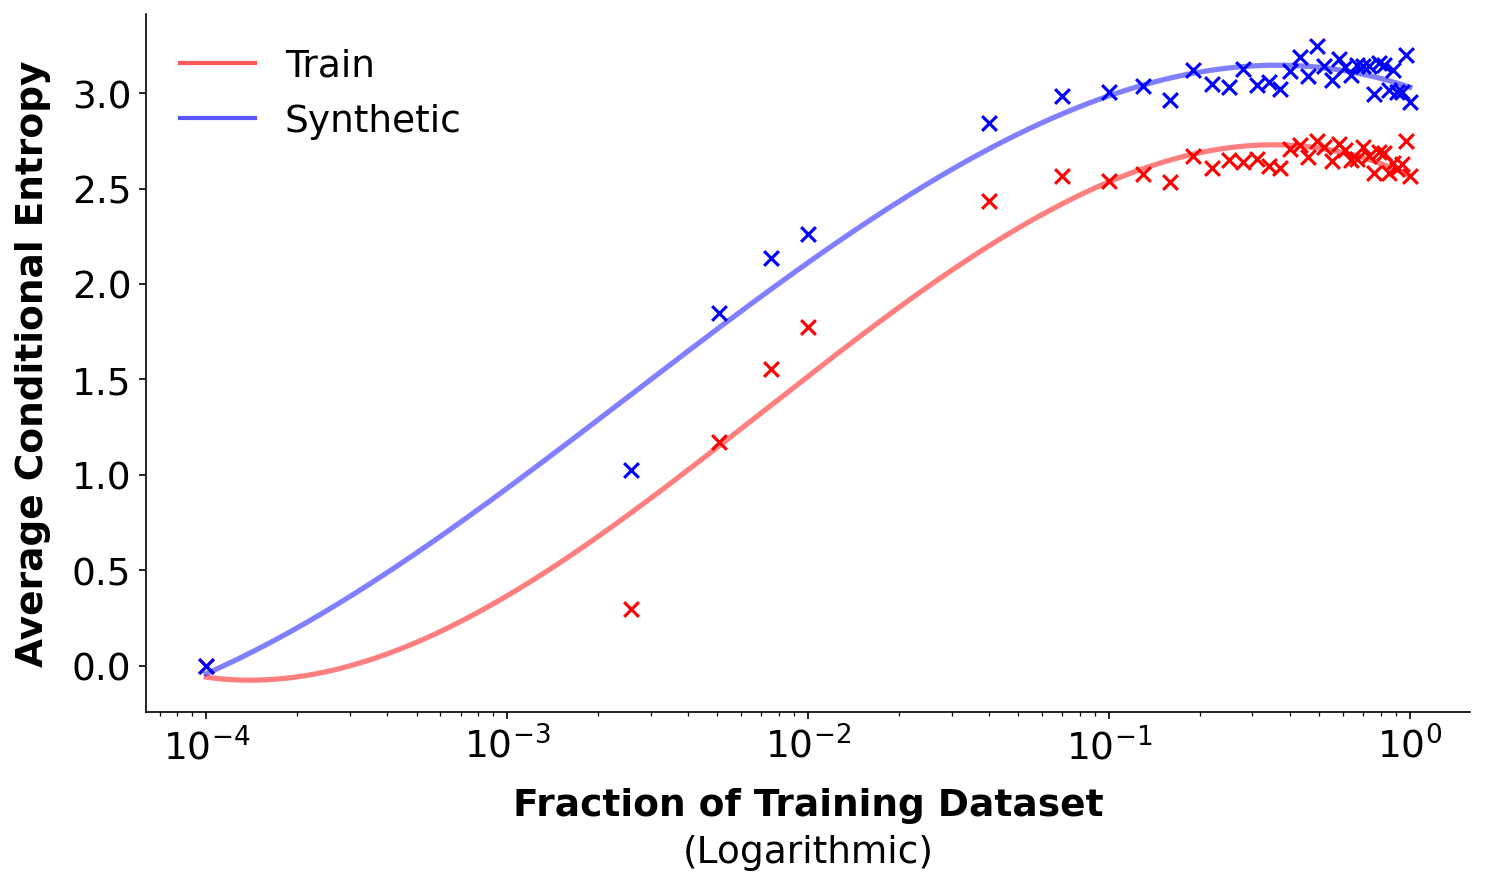

In [74]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
#plt.get_cmap('h')
#c = cm.OrRd_r(np.linspace(0, 1, 2))

fontsize=18

x_raw = np.array(stats1.x).astype('float')
y_real = stats1.avg_ent_real
y_fake = stats1.avg_ent_gen

p_real = np.poly1d(np.polyfit(np.log10(x_raw), y_real, deg=3))
p_fake = np.poly1d(np.polyfit(np.log10(x_raw), y_fake, deg=3))

x_smooth = np.logspace(np.log10(x_raw.min()), np.log10(x_raw.max()), 200)
y_real_smooth = p_real(np.log10(x_smooth))
y_fake_smooth = p_fake(np.log10(x_smooth))


ax.scatter(x_raw, y_real, color='red', marker='x', s=50)
ax.scatter(x_raw, y_fake, color='blue', marker='x', s=50)

ax.plot(x_smooth, y_real_smooth, color='red', linewidth=2.5, alpha=0.5, label='Train')
ax.plot(x_smooth, y_fake_smooth, color='blue', linewidth=2.5, alpha=0.5, label='Synthetic')

ax.set_xscale('log')
ax.set_xlabel('Fraction of Training Dataset', fontsize=fontsize, weight='bold', labelpad=10)
ax.set_ylabel('Average Conditional Entropy', fontsize=fontsize, weight='bold', labelpad=10)

ax.text(0.5, -0.175, '(Logarithmic)', transform=ax.transAxes, 
        fontsize=fontsize, weight='normal', ha='center', va='top')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Custom Legend Construction
from matplotlib.lines import Line2D
legend_elements = []
legend_elements.append(Line2D([0], [0], color='red', alpha=0.65, lw=2, label='Train'))
legend_elements.append(Line2D([0], [0], color='blue', alpha=0.65, lw=2, label='Synthetic'))

ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize=18)
#ax.grid(True, which="major", ls=":")
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()

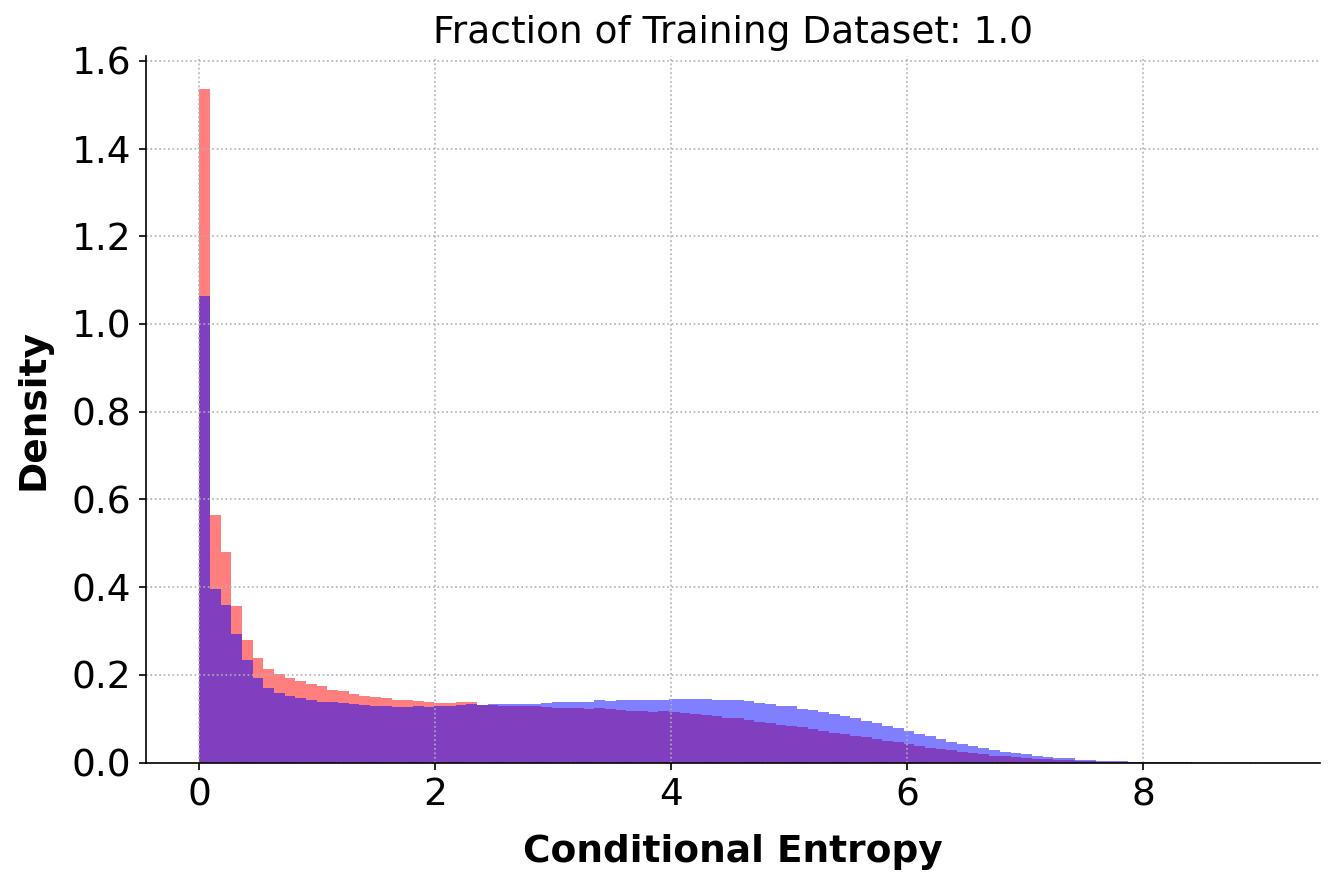

In [5]:
rows, cols = 1, 1

density = True
num_bins = 100

idx = -1

fig, ax = plt.subplots(rows, cols, figsize=(9, 6), dpi=150)

# Zip safely handles iteration
data_pairs = zip(stats1.ent_real, stats1.ent_gen)

real = stats1.ent_real[idx]
gen = stats1.ent_gen[idx]

real, gen = map(np.ravel, (real, gen))
combined_data = np.concatenate([real, gen])
bins = np.histogram_bin_edges(combined_data, bins=num_bins) 

ax.hist(real, bins=bins, density=density, alpha=0.5, label='Training', color='Red')
ax.hist(gen, bins=bins, density=density, alpha=0.5, label='Synthetic', color='Blue')

ax.tick_params(axis='both', labelsize=fontsize)

if idx == 0:
    ax.legend(loc='upper right', fontsize=fontsize)

ax.set_title(f"Fraction of Training Dataset: {stats1.x[idx]}", fontsize=fontsize)
ax.grid(True, which='major', ls=':')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.set_yscale('log')

ax.set_xlabel('Conditional Entropy', fontsize=fontsize, weight='bold', labelpad=10)
ax.set_ylabel('Density' if density else 'Count', fontsize=fontsize, weight='bold', labelpad=10)

plt.tight_layout()
plt.show()

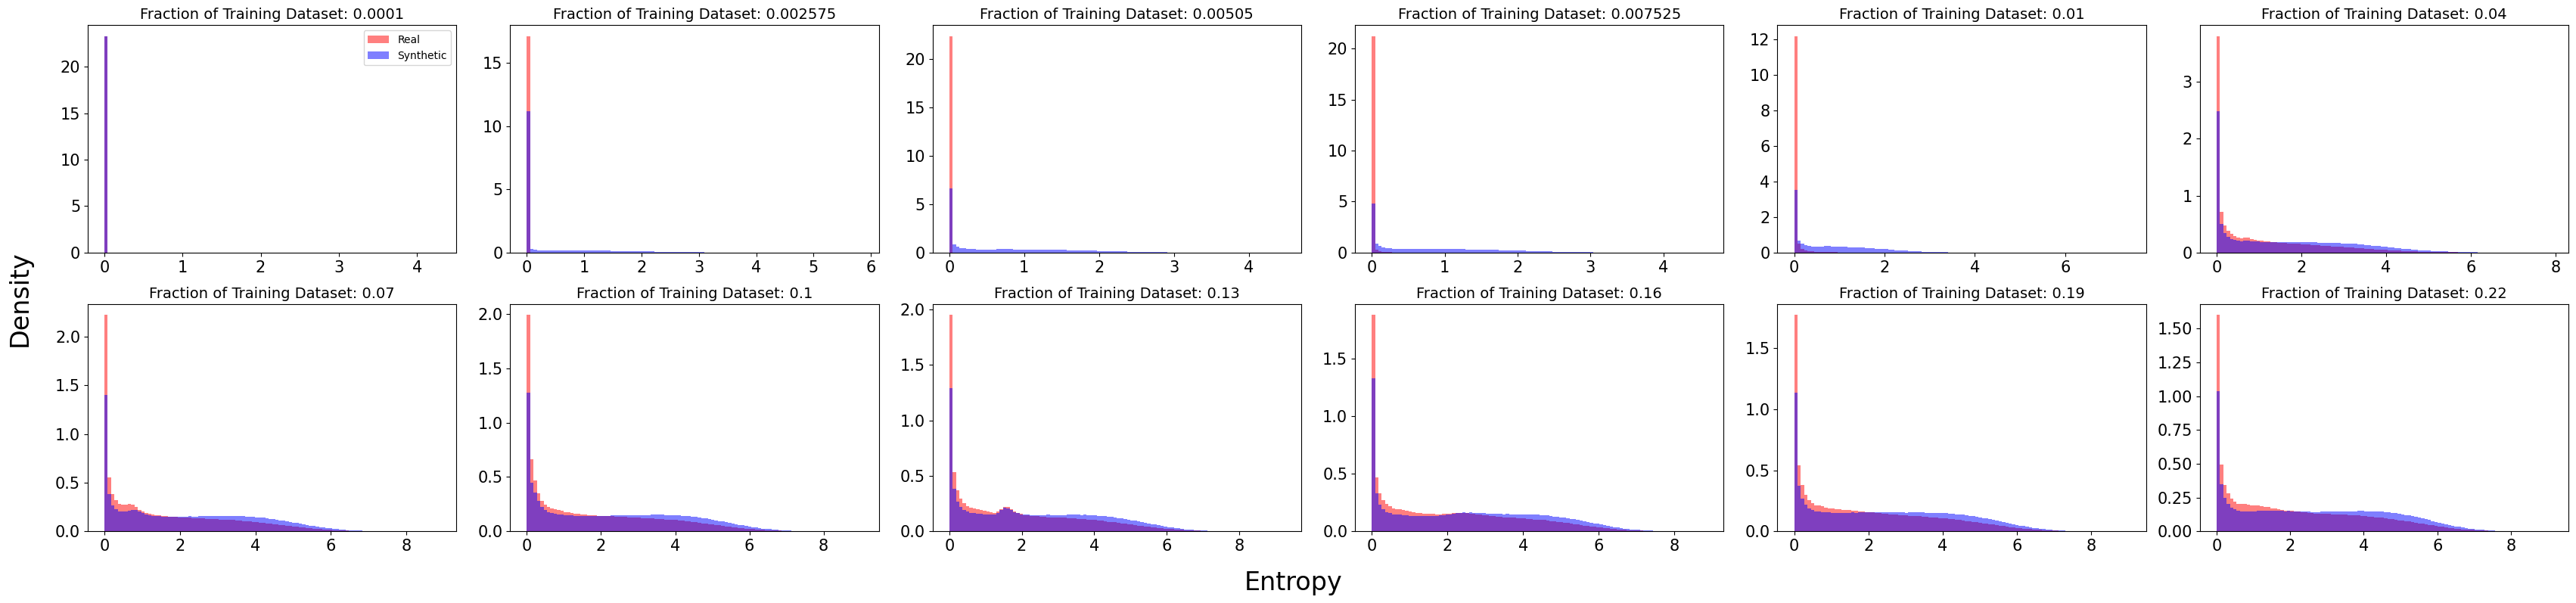

In [6]:
rows, cols = 2, 6

density = True
num_bins = 100

fig, axs = plt.subplots(rows, cols, figsize=(34, 8))
flat_axs = axs.flatten()

# Zip safely handles iteration
data_pairs = zip(stats1.ent_real, stats1.ent_gen)

for idx, (ax, (real, gen)) in enumerate(zip(flat_axs, data_pairs)):
    real, gen = map(np.ravel, (real, gen))
    # 1. Calculate shared bins based on the min/max of BOTH datasets
    # This ensures the bars align perfectly on the x-axis
    combined_data = np.concatenate([real, gen])
    bins = np.histogram_bin_edges(combined_data, bins=num_bins) 
    
    # 2. Plot Real Data
    # density=True ensures the area under the curve sums to 1
    ax.hist(real, bins=bins, density=density, alpha=0.5, label='Real', color='Red')
    
    # 3. Plot Generated Data
    ax.hist(gen, bins=bins, density=density, alpha=0.5, label='Synthetic', color='Blue')
    
    ax.tick_params(axis='both', labelsize=15)
    
    if idx == 0:
        ax.legend(loc='upper right')
    
    ax.set_title(f"Fraction of Training Dataset: {stats1.x[idx]}", fontsize=14)

# 2. Add the Shared Global Labels
fig.supxlabel("Entropy", fontsize=24)
fig.supylabel("Count" if not density else 'Density', fontsize=24, x=-0.00001)

# Hide unused plots
for i in range(len(stats1.ent_real), len(flat_axs)):
    flat_axs[i].axis('off')

plt.tight_layout()
plt.show()

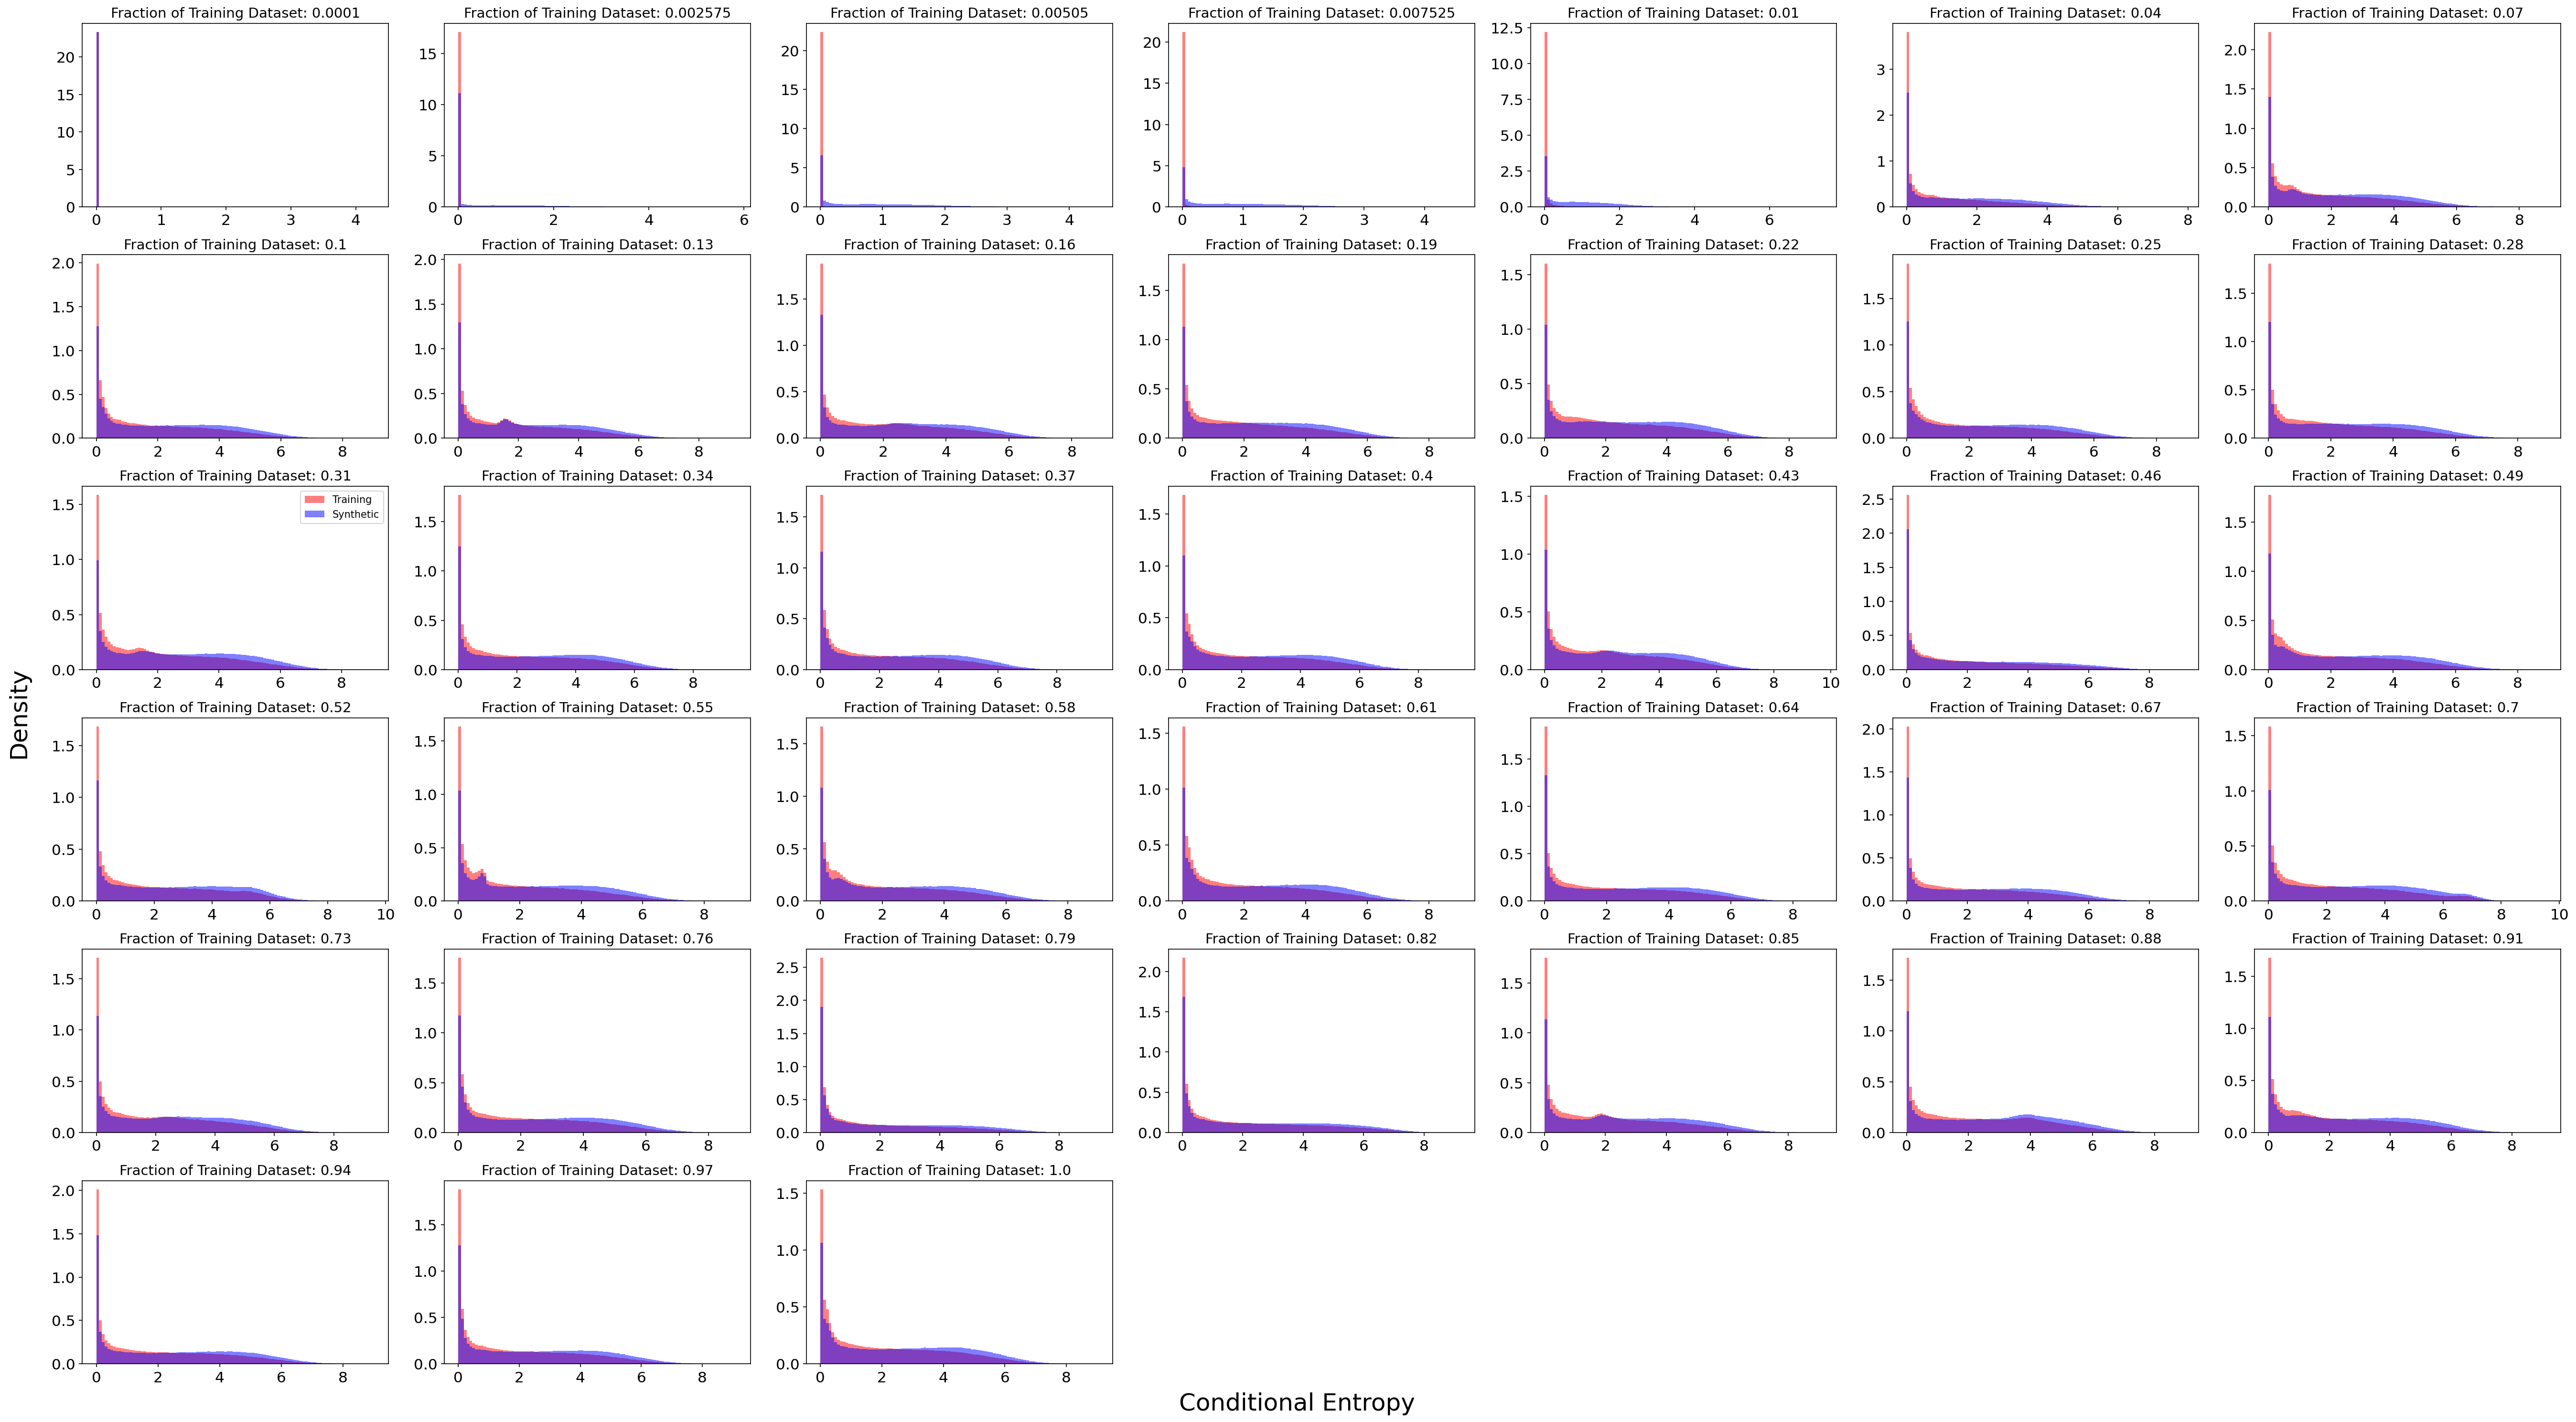

In [7]:
rows, cols = 6, 7

num_bins = 100
fig, axs = plt.subplots(rows, cols, figsize=(36, 20), dpi=150)
flat_axs = axs.flatten()

# Zip safely handles iteration
data_pairs = zip(stats1.ent_real, stats1.ent_gen)

for idx, (ax, (real, gen)) in enumerate(zip(flat_axs, data_pairs)):
    real, gen = map(lambda z: z.ravel(), (real, gen))
    
    # 1. Calculate shared bins based on the min/max of BOTH datasets
    # This ensures the bars align perfectly on the x-axis
    combined_data = np.concatenate([real, gen])
    bins = np.histogram_bin_edges(combined_data, bins=num_bins) 
    
    # 2. Plot Real Data
    # density=True ensures the area under the curve sums to 1
    ax.hist(real, bins=bins, density=density, alpha=0.5, label='Training', color='Red')
    
    # 3. Plot Generated Data
    ax.hist(gen, bins=bins, density=density, alpha=0.5, label='Synthetic', color='Blue')
    
    ax.tick_params(axis='both', labelsize=15)
    
    if idx == 14:
        ax.legend(loc='upper right')
    
    ax.set_title(f"Fraction of Training Dataset: {stats1.x[idx]}", fontsize=14)

# 2. Add the Shared Global Labels
fig.supxlabel("Conditional Entropy", fontsize=24)
fig.supylabel("Count" if not density else 'Density', fontsize=24, x=-0.00001)

# Hide unused plots
for i in range(len(stats1.ent_real), len(flat_axs)):
    flat_axs[i].axis('off')

plt.tight_layout()
plt.show()

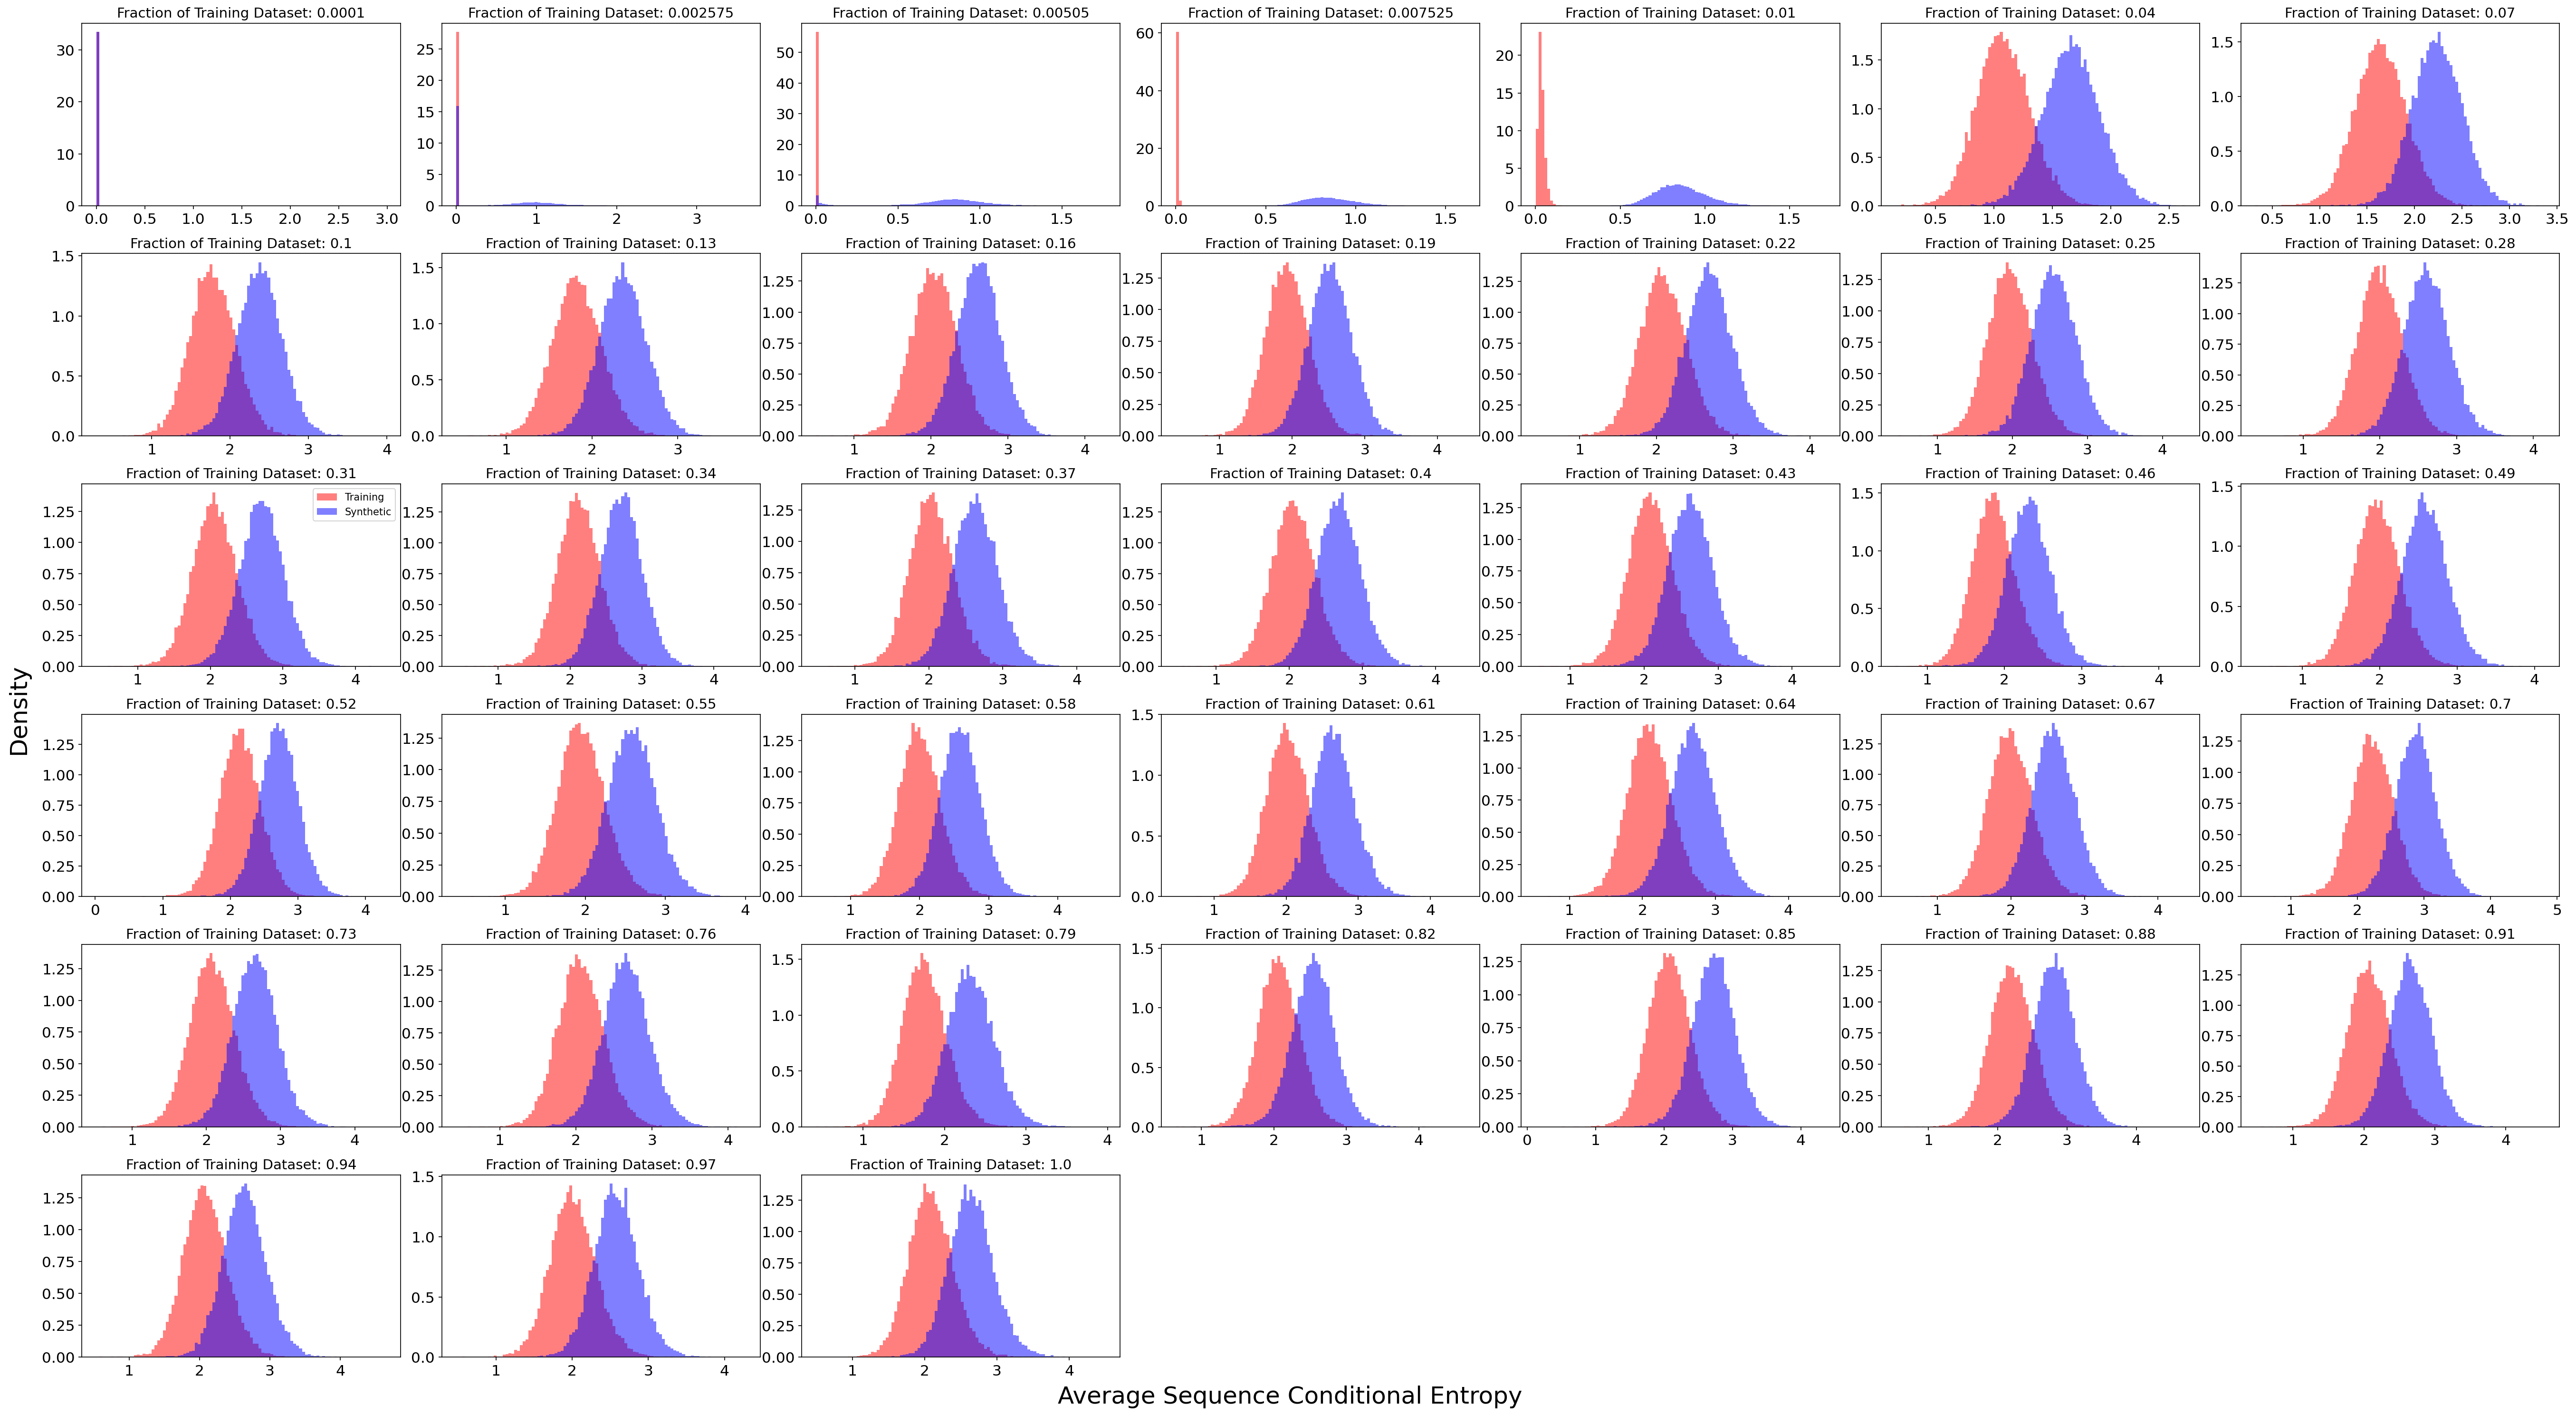

In [8]:
rows, cols = 6, 7

num_bins = 100
fig, axs = plt.subplots(rows, cols, figsize=(36, 20), dpi=150)
flat_axs = axs.flatten()

# Zip safely handles iteration
data_pairs = zip(stats1.ent_real, stats1.ent_gen)

for idx, (ax, (real, gen)) in enumerate(zip(flat_axs, data_pairs)):
    real, gen = map(lambda z: z.mean(1), (real, gen))
    
    # 1. Calculate shared bins based on the min/max of BOTH datasets
    # This ensures the bars align perfectly on the x-axis
    combined_data = np.concatenate([real, gen])
    bins = np.histogram_bin_edges(combined_data, bins=num_bins) 
    
    # 2. Plot Real Data
    # density=True ensures the area under the curve sums to 1
    ax.hist(real, bins=bins, density=density, alpha=0.5, label='Training', color='Red')
    
    # 3. Plot Generated Data
    ax.hist(gen, bins=bins, density=density, alpha=0.5, label='Synthetic', color='Blue')
    
    ax.tick_params(axis='both', labelsize=15)
    
    if idx == 14:
        ax.legend(loc='upper right')
    
    ax.set_title(f"Fraction of Training Dataset: {stats1.x[idx]}", fontsize=14)

# 2. Add the Shared Global Labels
fig.supxlabel("Average Sequence Conditional Entropy", fontsize=24)
fig.supylabel("Count" if not density else 'Density', fontsize=24, x=-0.00001)

# Hide unused plots
for i in range(len(stats1.ent_real), len(flat_axs)):
    flat_axs[i].axis('off')

plt.tight_layout()
plt.show()